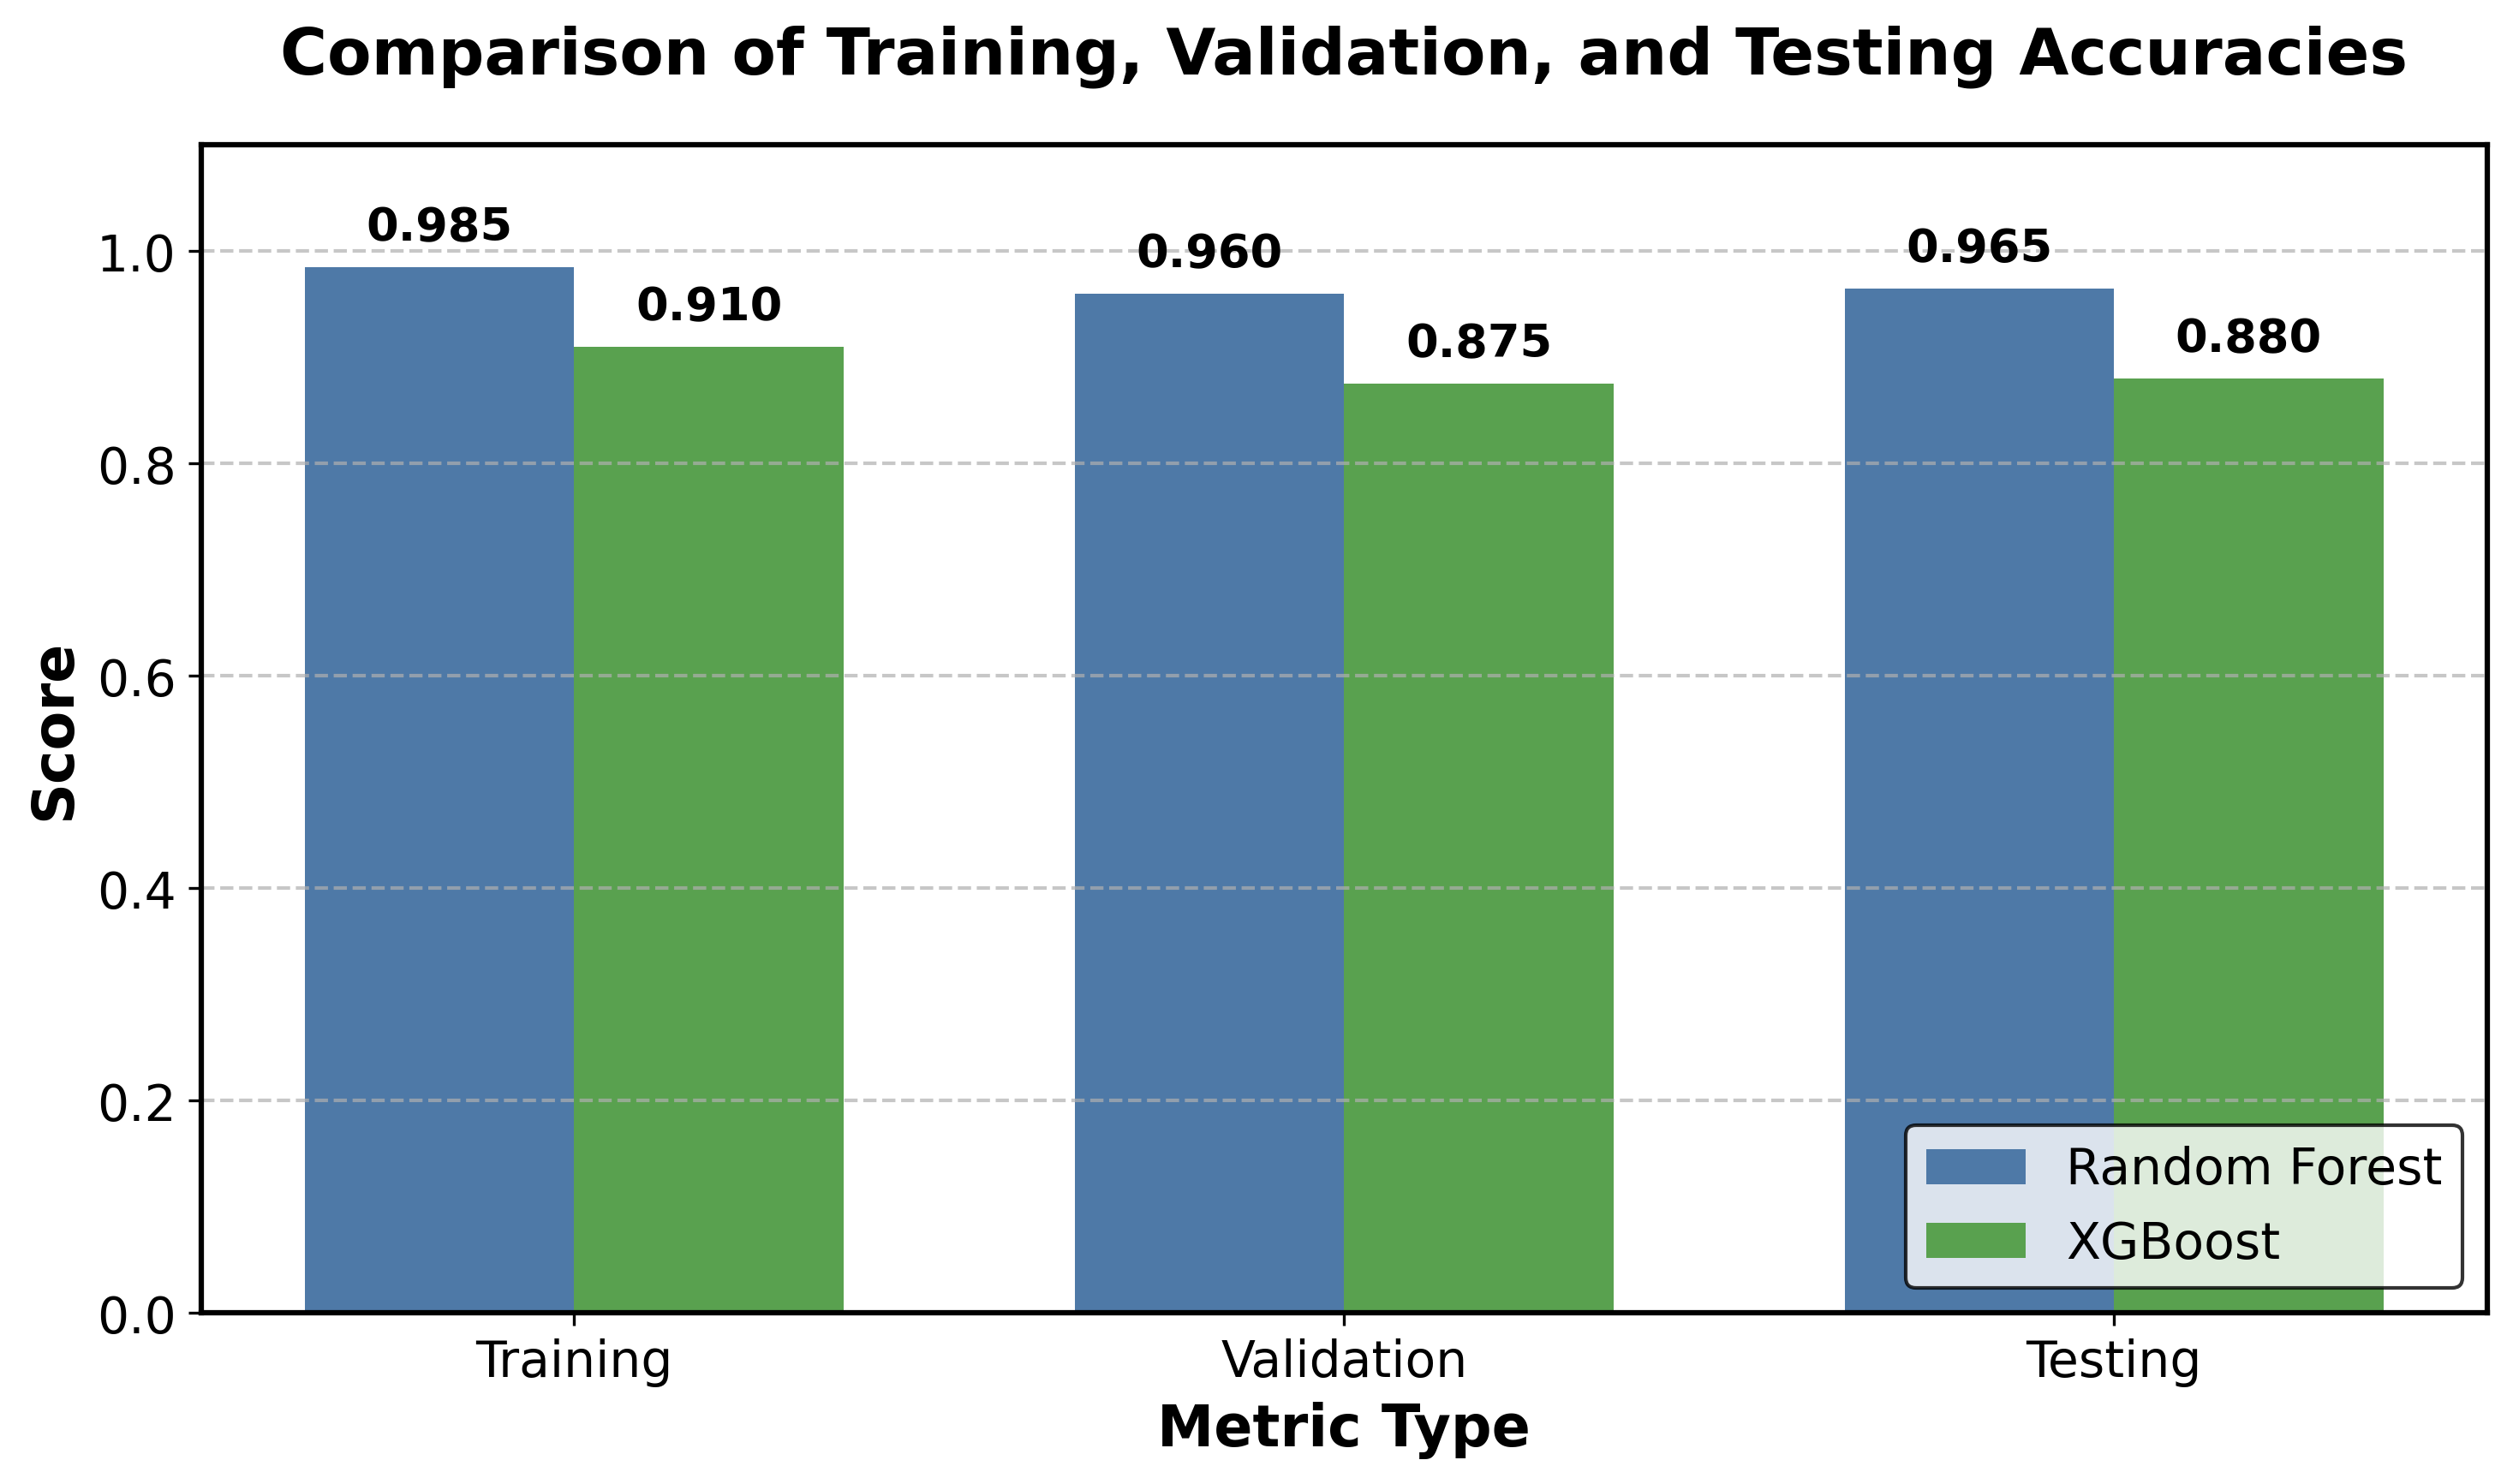

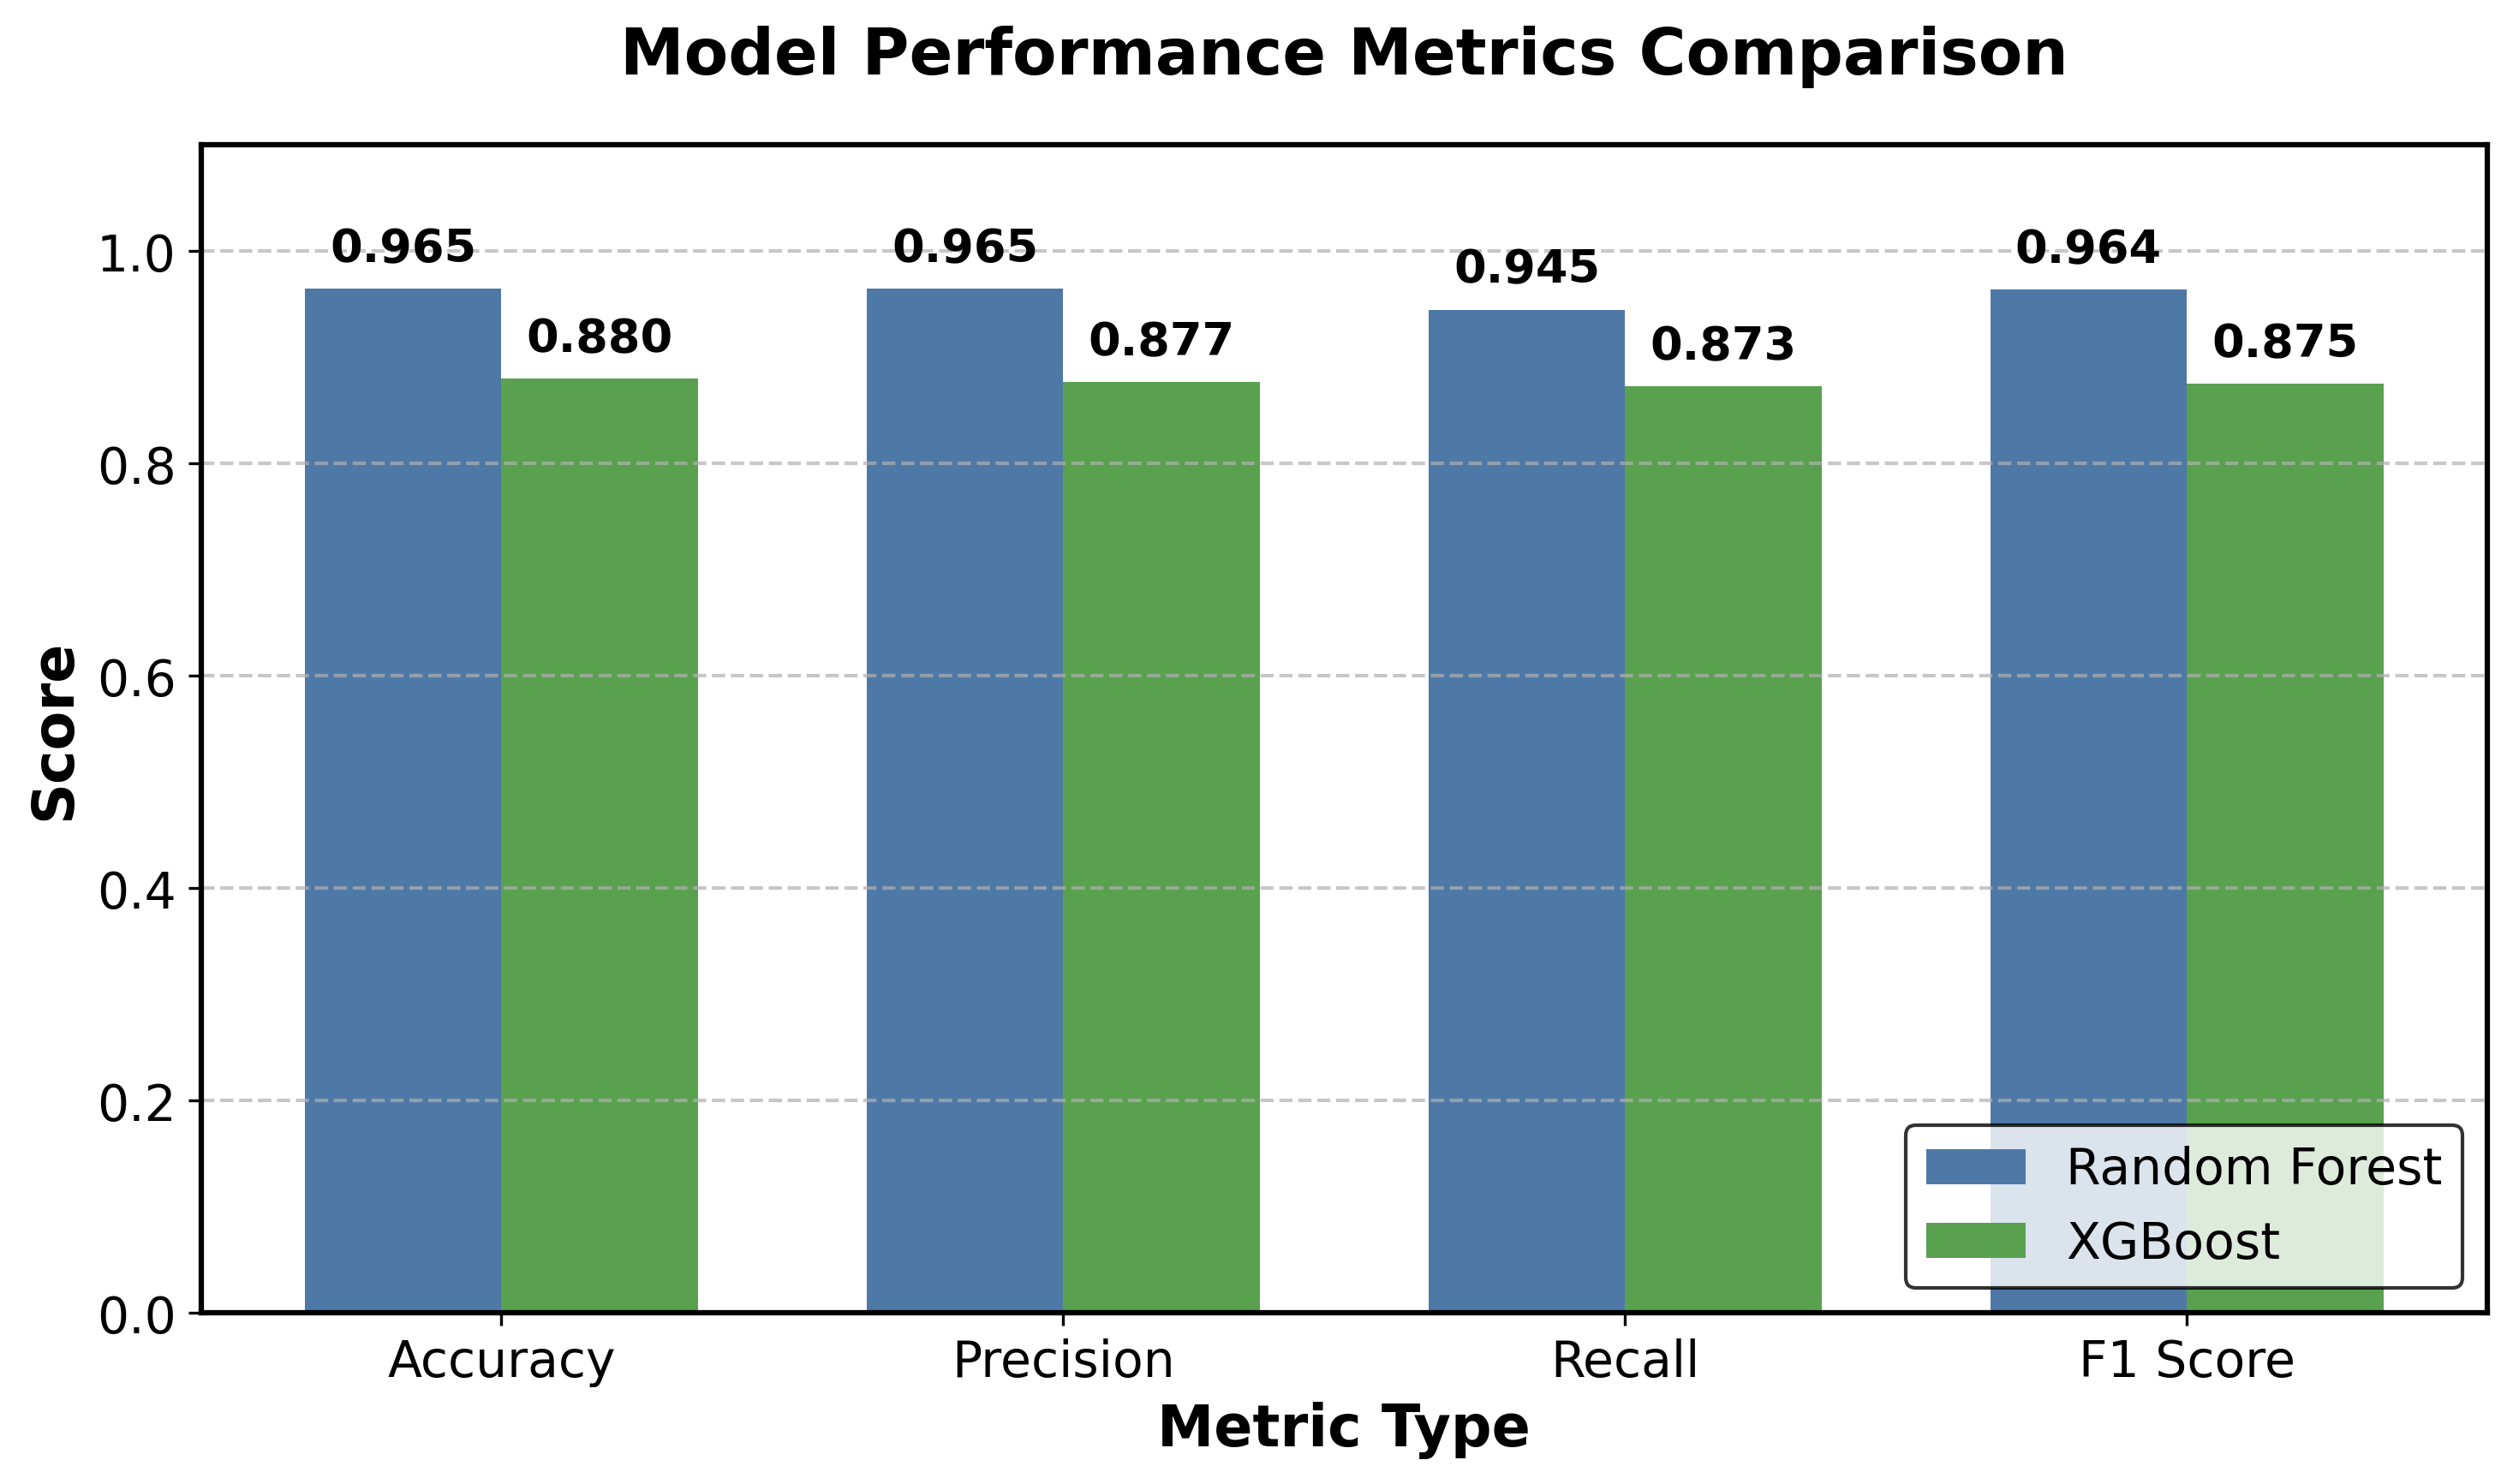

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Global IEEE Configuration ---
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 14,             # Minimum 12pt requested
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'font.family': 'sans-serif', # Standard for conference papers
    'axes.linewidth': 1.5        # Thickened axes lines
})

# Data for Figure 1: Accuracy Comparison
metrics_acc = ['Training', 'Validation', 'Testing']
rf_acc = [0.985, 0.960, 0.965]
xgb_acc = [0.910, 0.875, 0.880]

# Data for Figure 2: Model Metrics
metrics_eval = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
rf_eval = [0.965, 0.965, 0.945, 0.964] # Corrected Random Forest Precision from 0.988 to 0.965
xgb_eval = [0.880, 0.877, 0.873, 0.875]

def create_ieee_bar_chart(labels, model1_data, model2_data, title, filename):
    x = np.arange(len(labels))
    width = 0.35  # Thicker bars for better visibility

    fig, ax = plt.subplots(figsize=(10, 6)) # 10 inches wide for single column

    rects1 = ax.bar(x - width/2, model1_data, width, label='Random Forest', color='#4E79A7')
    rects2 = ax.bar(x + width/2, model2_data, width, label='XGBoost', color='#59A14F')

    # Add labels, title and custom x-axis tick labels
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_xlabel('Metric Type', fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.1) # Leave space for labels at the top

    ax.legend(loc='lower right', frameon=True, edgecolor='black')
    ax.grid(axis='y', linestyle='--', alpha=0.7, linewidth=1.0)

    # --- Step 4: Explicit Label Font Sizes ---
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),  # 5 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=13, fontweight='bold') # Clearly visible labels

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    # Save as high-res PNG
    plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Generate both figures
create_ieee_bar_chart(metrics_acc, rf_acc, xgb_acc,
                      'Comparison of Training, Validation, and Testing Accuracies',
                      'fig_accuracy_comparison_v2')

create_ieee_bar_chart(metrics_eval, rf_eval, xgb_eval,
                      'Model Performance Metrics Comparison',
                      'fig_model_metrics_v2')